# Sphere of influence calculation

For a reliable mass measurement using JAM modelling we want the sphere of influence of the black hole to be resolved. The sphere of influence of a BH is given by:

$$r_{soi} = \frac{GM_{BH}}{\sigma^2}$$

For Sombrero we have a previous BH mass estimate of $M_{BH} = 6.6 \times 10^8 M_{\odot}$ (Jardel et al. 2011), the velocity dispersion we can directly read from the NIRSPEC data and we can use the distance based on TRGB stars of 9.55Mpc

In [7]:
import astropy.units as u
import numpy as np
import astropy.constants as const
from astropy.table import Table
import matplotlib.pyplot as plt

In [ ]:
def sphere_of_influence(M_BH, sigma):
    """
    Calculate the sphere of influence of a black hole.

    Parameters:
    M_BH : float
        Mass of the black hole in solar masses.
    sigma : float
        Velocity dispersion in km/s.

    Returns:
    r_soi : float
        Sphere of influence radius in parsecs.
    """
    G = const.G.to(u.pc * u.km**2 / (u.s**2 * u.Msun)).value  # Gravitational constant in pc km^2 / s^2 / Msun
    r_soi = G * M_BH / sigma**2  # Sphere of influence radius in parsecs
    return r_soi

In [13]:
m_bh = 6.6e8  # Mass of the black hole in solar masses
distance = 9.55 * u.Mpc  # Distance to the galaxy in megaparsecs

## Get the velicity dispersion

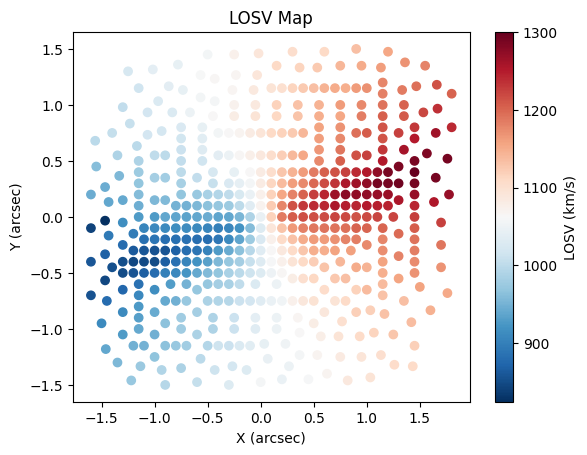

In [ ]:
# load the nirspec data
# the file is a csv with the format:
# X;Y;LOSV;LOSV_err;sigma;sigma_err;h3;h4
kin_table = Table.read("/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/IFU/antoine/M104_stellar_Kin.csv", format="csv", delimiter=";")
# make a plot just a scatter
plt.scatter(kin_table["X"], kin_table["Y"], c=kin_table["LOSV"], cmap="RdBu_r")
plt.colorbar(label="LOSV (km/s)")
plt.xlabel("X (arcsec)")
plt.ylabel("Y (arcsec)")
plt.title("LOSV Map")
plt.show()

In [20]:
max_sigma = np.max(kin_table["sigma"])
r_soi = sphere_of_influence(m_bh, max_sigma)
print(f"Sphere of influence radius: {r_soi:.2f} pc")
# convert r_soi to arcseconds

r_soi_arcsec = (r_soi * u.pc / distance.to(u.pc)) * 206265  # Convert to arcseconds
print(f"Sphere of influence radius: {r_soi_arcsec:.2f} arcseconds")

Sphere of influence radius: 37.12 pc
Sphere of influence radius: 0.80 arcseconds


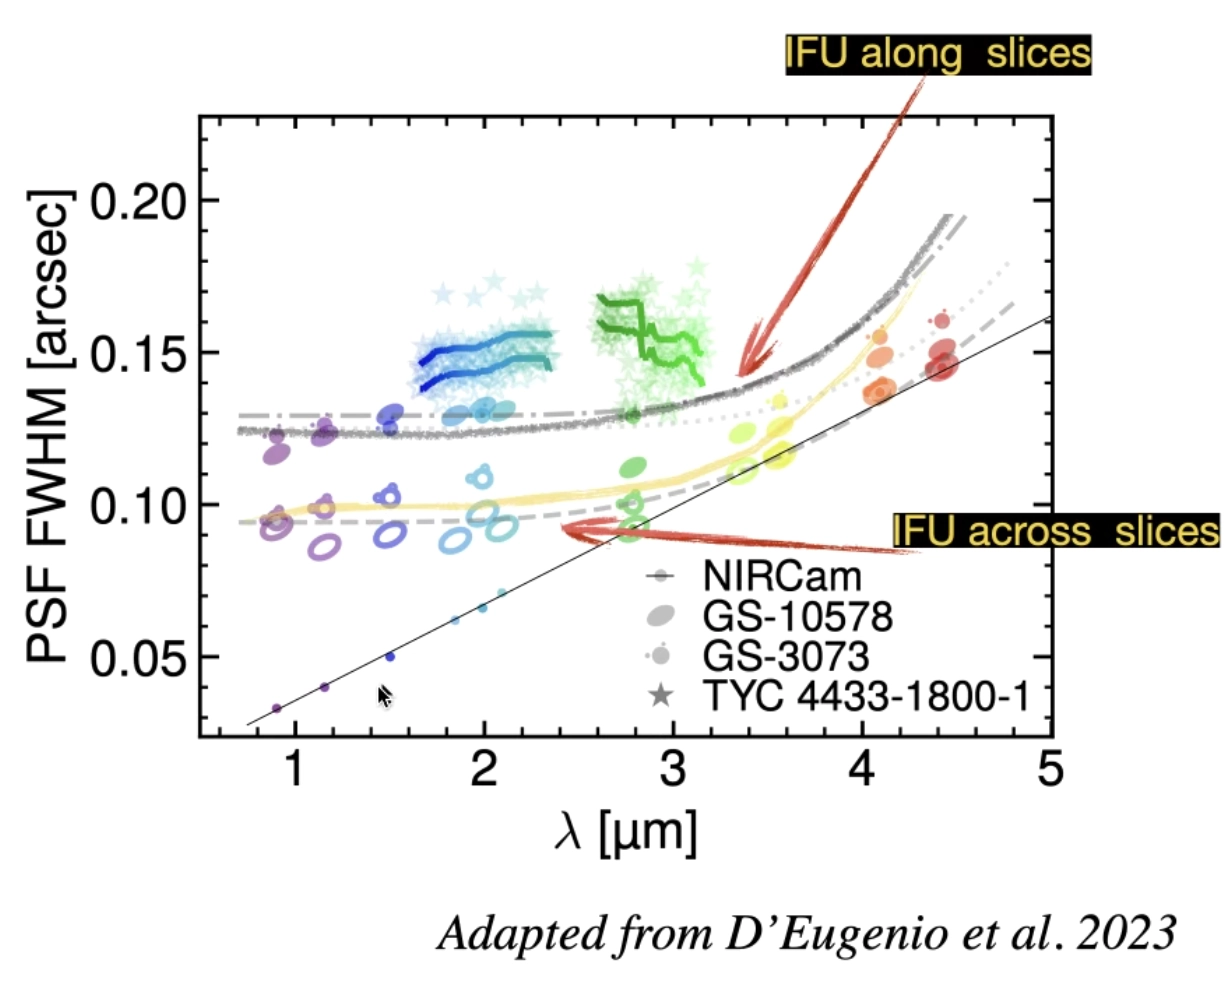

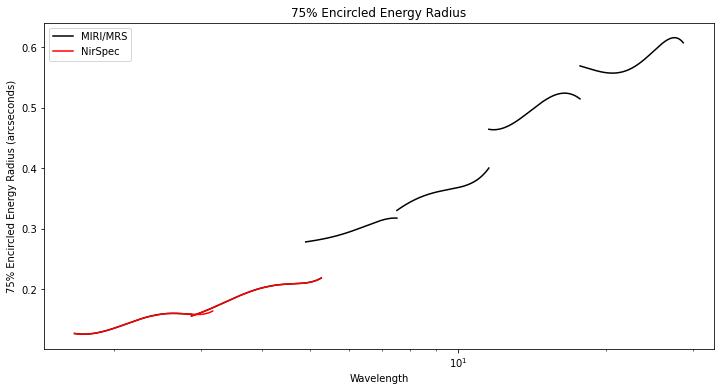